In [1]:
import pandas as pd
import numpy as np
import re
from scripts import mcmc
from scripts import stability_analysis
from scripts import fem_vis
from scripts import fem_solve

#import matplotlib
#matplotlib.use('QtAgg')
%matplotlib inline
import matplotlib.pyplot as plt

NUM = re.compile(r"[-+]?(?:\d+\.?\d*|\.\d+)(?:[eE][-+]?\d+)?")

In [2]:
df = pd.read_csv("results/08_10_2026_mcmc_results/fem_evals.csv")

params = df['Parameters']

print(params)

values = df['Value']
wid = df['Walker']
params_arr = []
values_arr = []
wid_arr = []

for i, param in enumerate(params):
    params_arr.append(mcmc._parse_params(param, n_params=7))
    values_arr.append(values.loc[i])
    wid_arr.append(wid.loc[i])

params_arr = np.asarray(params_arr)
values_arr = np.asarray(values_arr)
wid_arr = np.asarray(wid_arr)

# ignore the 1e+33 values
ignore_args = np.where(values_arr!=1e+33)
values_arr = values_arr[ignore_args]
wid_arr = wid_arr[ignore_args]
params_arr = params_arr[ignore_args]

#print(values_arr)
#print(params_arr)

print(np.mean(np.log(values_arr)))
print(np.std(np.log(values_arr)))

0       [  2.10702247, 99.79570889,  7.68709883, 19.04...
1       [ 14.53144484, 98.36261192,  6.30434108,  6.37...
2       [  4.00504785,136.55727936,  3.8895657 , 16.37...
3       [ 18.4151976 ,134.74317681,  7.61282819, 14.95...
4       [ 16.59310433,102.46955523,  9.42911625, 12.51...
                              ...                        
8595    [  0.42962166,125.4475233 ,  7.00043569,  5.80...
8596    [  0.13608828,107.6897977 ,  4.25683366,  6.05...
8597    [  1.05382549,125.4900914 ,  3.6675732 ,  3.97...
8598    [  0.35598332,128.70182299,  4.03317096, 12.54...
8599    [  2.53410609,125.89619857,  5.1723322 ,  7.64...
Name: Parameters, Length: 8600, dtype: str
72.19716627346841
0.2612302221041061


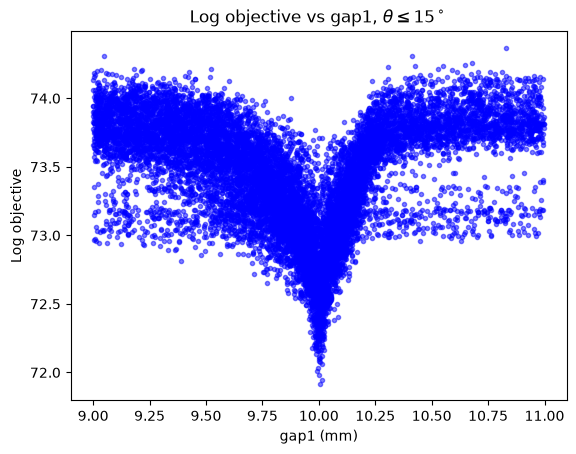

In [19]:
# sort by where theta is
small_theta_args = np.where(theta_vals<=15)
large_theta_args = np.where(theta_vals>15)
gap_1_small_theta = gap1_vals[small_theta_args]
gap_1_large_theta = gap1_vals[large_theta_args]
small_theta_values = values_arr[small_theta_args]
large_theta_values = values_arr[large_theta_args]

fig,ax=plt.subplots()
ax.scatter(gap_1_small_theta, np.log(small_theta_values), marker='.', c='b', alpha=0.5)
#ax.scatter(gap_1_large_theta, np.log(large_theta_values), marker='.', c='b', alpha=0.5)
ax.set_ylabel('Log objective')
ax.set_xlabel('gap1 (mm)')
ax.set_title('Log objective vs gap1, $\\theta\\leq15^\\circ$')
plt.show()

In [20]:
fig,ax=plt.subplots(5, 2, figsize=(6,15))
ax_flat = ax.flatten()
for walker_id in range(10):
    walker_id_args = np.where(wid_arr==walker_id)
    gap1_vals_wid = gap1_vals[walker_id_args]
    values_wid = values_arr[walker_id_args]
    print(f'best result for walker id {walker_id}: {np.min(values_wid)}')
    ax_flat[walker_id].scatter(gap1_vals_wid, np.log(values_wid), marker='.', c='b')
plt.tight_layout()
plt.show()

best result for walker id 0: 1.7119303620295577e+31
best result for walker id 1: 2.2444008368071343e+31
best result for walker id 2: 2.2589633615759326e+31
best result for walker id 3: 1.87403471120526e+31
best result for walker id 4: 2.426209811129673e+31
best result for walker id 5: 2.1271927419587635e+31
best result for walker id 6: 1.9139825267104367e+31
best result for walker id 7: 2.081229384764981e+31
best result for walker id 8: 1.824567283731694e+31
best result for walker id 9: 2.153531502706908e+31


KeyboardInterrupt: 

In [3]:
best = np.argsort(values_arr)
t10_params = params_arr[best][:10]
print(values_arr[best][:10])
print(t10_params)

best_params = params_arr[best][0]
print(best_params)
#print(mcmc.fom(best_params, verbose=True))

[1.40419223e+31 1.42263297e+31 1.43876549e+31 1.45683773e+31
 1.45721671e+31 1.45774774e+31 1.45906749e+31 1.46192404e+31
 1.46425353e+31 1.46890706e+31]
[[1.68993490e-01 1.28746691e+02 5.83007533e+00 9.41222406e+00
  1.09485037e+01 1.23212964e+02 1.24938011e+02]
 [1.80882621e+00 1.26715365e+02 3.66510647e+00 7.04553869e+00
  7.82396745e+00 1.20455815e+02 1.19329582e+02]
 [7.71740510e-01 1.26407315e+02 3.14624887e+00 7.31542385e+00
  7.12345959e+00 1.25064038e+02 1.24214031e+02]
 [5.74774579e-02 1.25455172e+02 3.64243912e+00 7.11634339e+00
  7.72316918e+00 1.22077045e+02 1.21339067e+02]
 [2.58776570e-01 1.28679036e+02 3.23918675e+00 9.15160435e+00
  9.46003310e+00 1.20654378e+02 1.19986292e+02]
 [1.39531428e+00 1.29858679e+02 3.63980787e+00 8.87375599e+00
  1.00192134e+01 1.23604751e+02 1.24720695e+02]
 [6.51372124e+00 1.25259101e+02 3.54043696e+00 7.00731821e+00
  7.33553891e+00 1.20277898e+02 1.19764896e+02]
 [2.99769060e-01 1.26803461e+02 3.42153207e+00 6.96152880e+00
  6.91159664e+

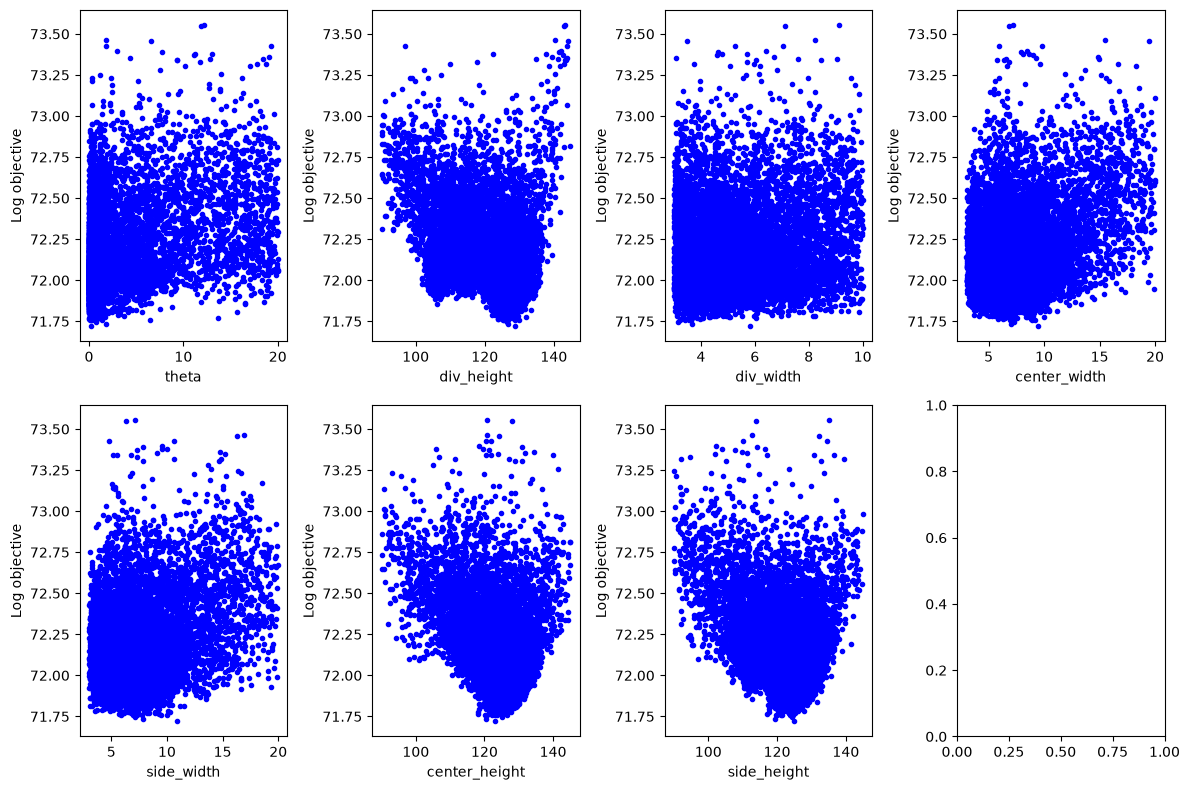

In [4]:
param_names = ['theta', 'div_height', 'div_width', 'center_width', 'side_width', 'center_height', 'side_height']
num_params = len(param_names)
fig, ax = plt.subplots(2,4, figsize=(12,8))
ax_flat = ax.flatten()

for i, name in enumerate(param_names):
    ax_flat[i].scatter(params_arr[:,i], np.log(values_arr), c='b', marker='.')
    ax_flat[i].set_xlabel(name)
    ax_flat[i].set_ylabel("Log objective")

plt.tight_layout()
plt.show()

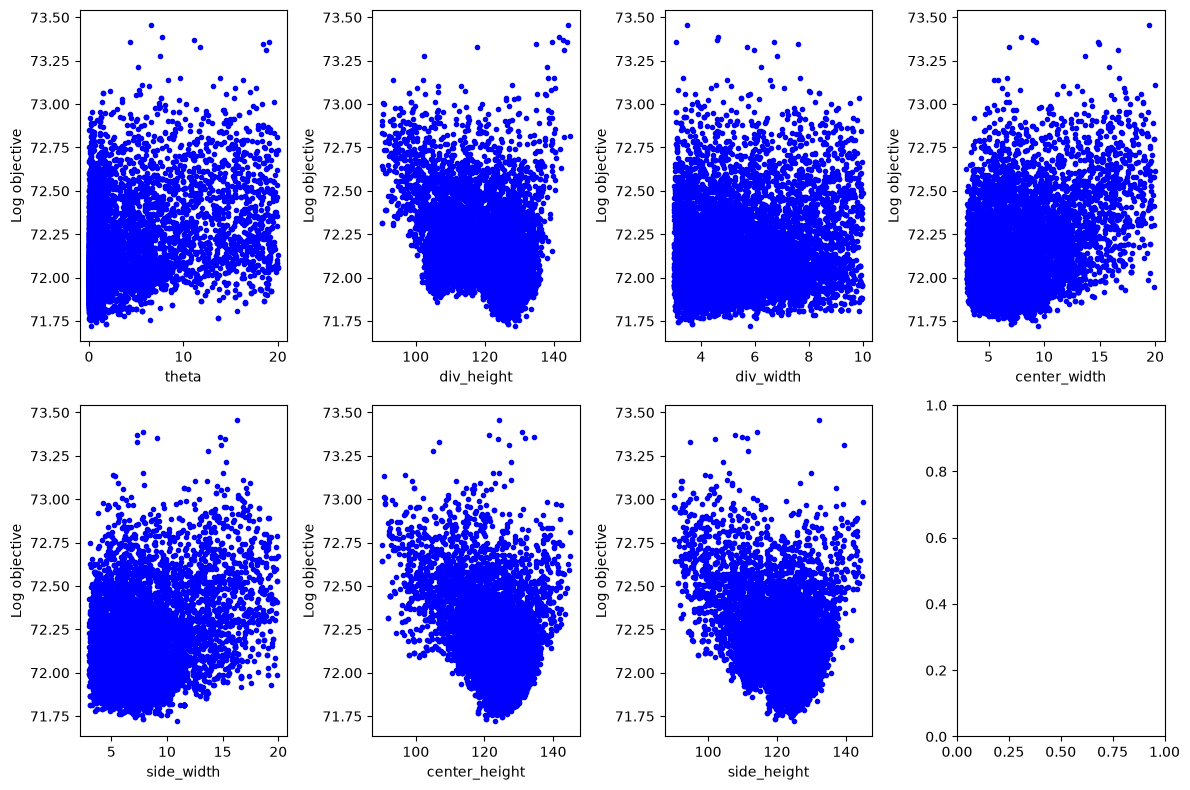

In [5]:
df_all = pd.read_csv('results/08_10_2026_mcmc_results/all_params_all_values.csv')
params_all = df_all['Parameters']
values_all = df_all['Value']
wid_all = df_all['Walker']
params_arr_all = []
values_arr_all = []
wid_arr_all = []

for i, param in enumerate(params_all):
    params_arr_all.append(mcmc._parse_params(param, n_params=7))
    values_arr_all.append(values_all.loc[i])
    wid_arr_all.append(wid_all.loc[i])

params_arr_all = np.asarray(params_arr_all)
values_arr_all = np.asarray(values_arr_all)
wid_arr_all = np.asarray(wid_arr_all)

ignore_args_all = np.where(values_arr_all!=1e+33)
values_arr_all = values_arr_all[ignore_args_all]
wid_arr_all = wid_arr_all[ignore_args_all]
params_arr_all = params_arr_all[ignore_args_all]

param_names = ['theta', 'div_height', 'div_width', 'center_width', 'side_width', 'center_height', 'side_height']
num_params = len(param_names)
fig, ax = plt.subplots(2, 4, figsize=(12,8))
ax_flat = ax.flatten()

for i, name in enumerate(param_names):
    ax_flat[i].scatter(params_arr_all[:,i], np.log(values_arr_all), c='b', marker='.')
    ax_flat[i].set_xlabel(name)
    ax_flat[i].set_ylabel("Log objective")

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Log objective')

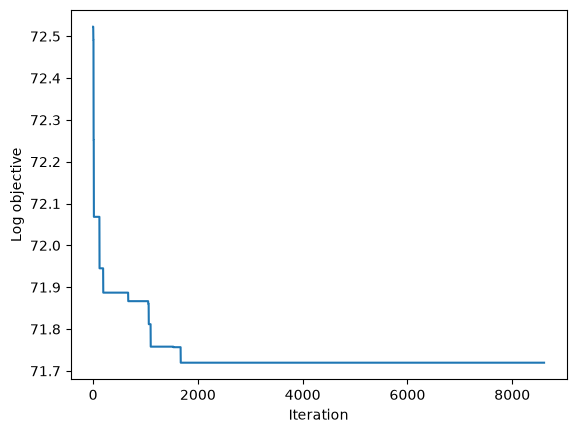

In [6]:
# best so far plot

best_so_far = np.minimum.accumulate(values_arr_all)
fig, ax = plt.subplots()
ax.plot(np.linspace(1, len(best_so_far), len(best_so_far)), np.log(best_so_far))
ax.set_xlabel('Iteration')
ax.set_ylabel('Log objective')

859


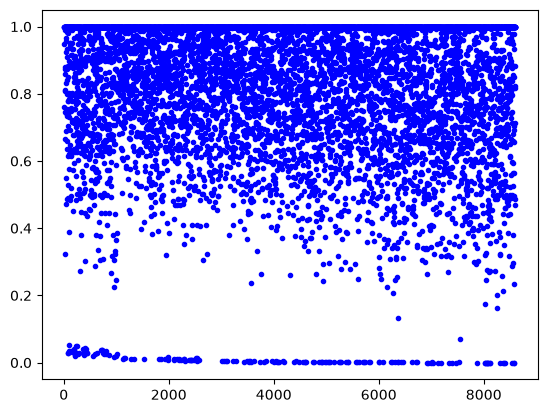

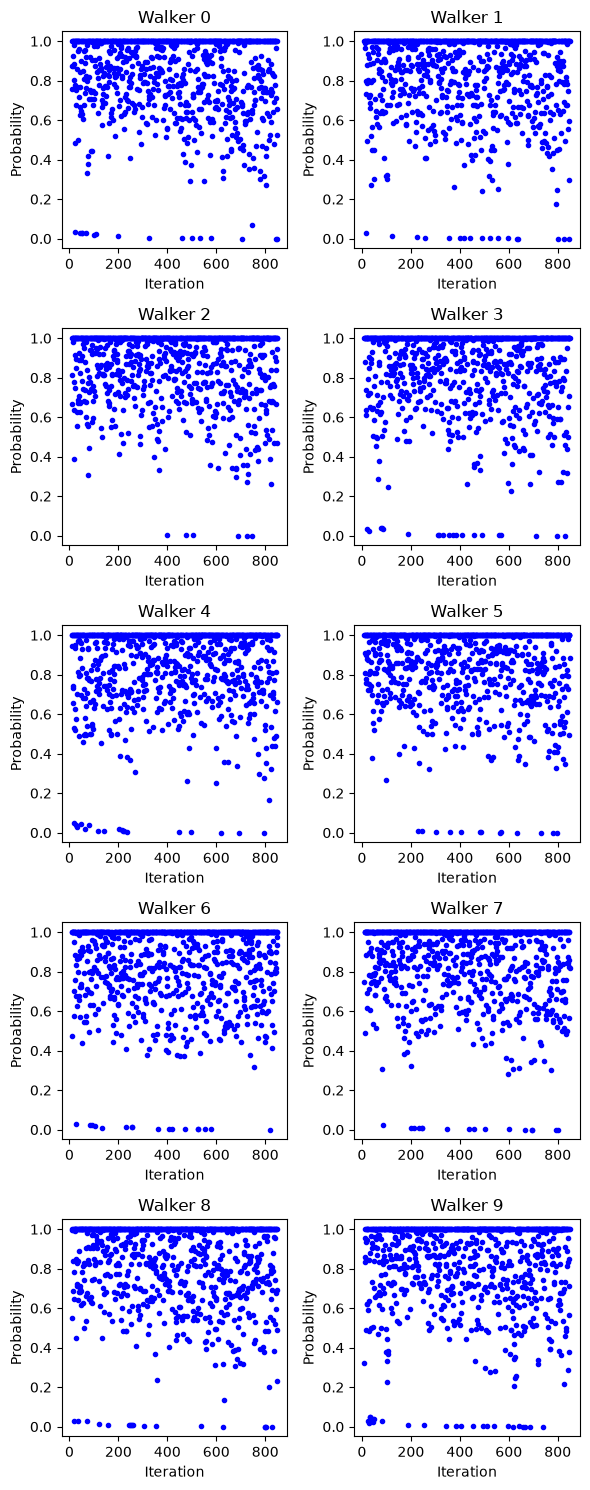

In [7]:
probs = df["AcceptProb"]
fig, ax = plt.subplots()
ax.scatter(probs[-np.isnan(df["AcceptProb"])].index, probs[-np.isnan(df["AcceptProb"])], marker='.', c='b')

probs = np.asarray(probs)
wid_arr = np.asarray(wid)

fig,ax=plt.subplots(5, 2, figsize=(6,15))
ax_flat = ax.flatten()
for walker_id in range(10):
    walker_id_args = np.where(wid_arr==walker_id)
    probs_wid = probs[walker_id_args]
    probs_wid = probs_wid[~np.isnan(probs_wid)]
    inds = np.linspace(10, len(probs_wid)-10, len(probs_wid))
    #print(len(inds))
    #print(f'best result for walker id {walker_id}: {np.min(values_wid)}')
    ax_flat[walker_id].scatter(inds, probs_wid, marker='.', c='b')
    ax_flat[walker_id].set_title(f'Walker {walker_id}')
    ax_flat[walker_id].set_xlabel('Iteration')
    ax_flat[walker_id].set_ylabel('Probability')

print(len(inds))
plt.tight_layout()
plt.show()


range for theta: [np.float64(0.0397028395), np.float64(13.67036317)]
range for div_height: [np.float64(123.78634922), np.float64(131.88294389)]
range for div_width: [np.float64(3.10563036), np.float64(6.05058759)]
range for center_width: [np.float64(5.88396674), np.float64(10.0237305)]
range for side_width: [np.float64(5.70686514), np.float64(10.9485037)]
range for center_height: [np.float64(118.079862), np.float64(127.634135)]
range for side_height: [np.float64(117.04119294), np.float64(125.27971523)]


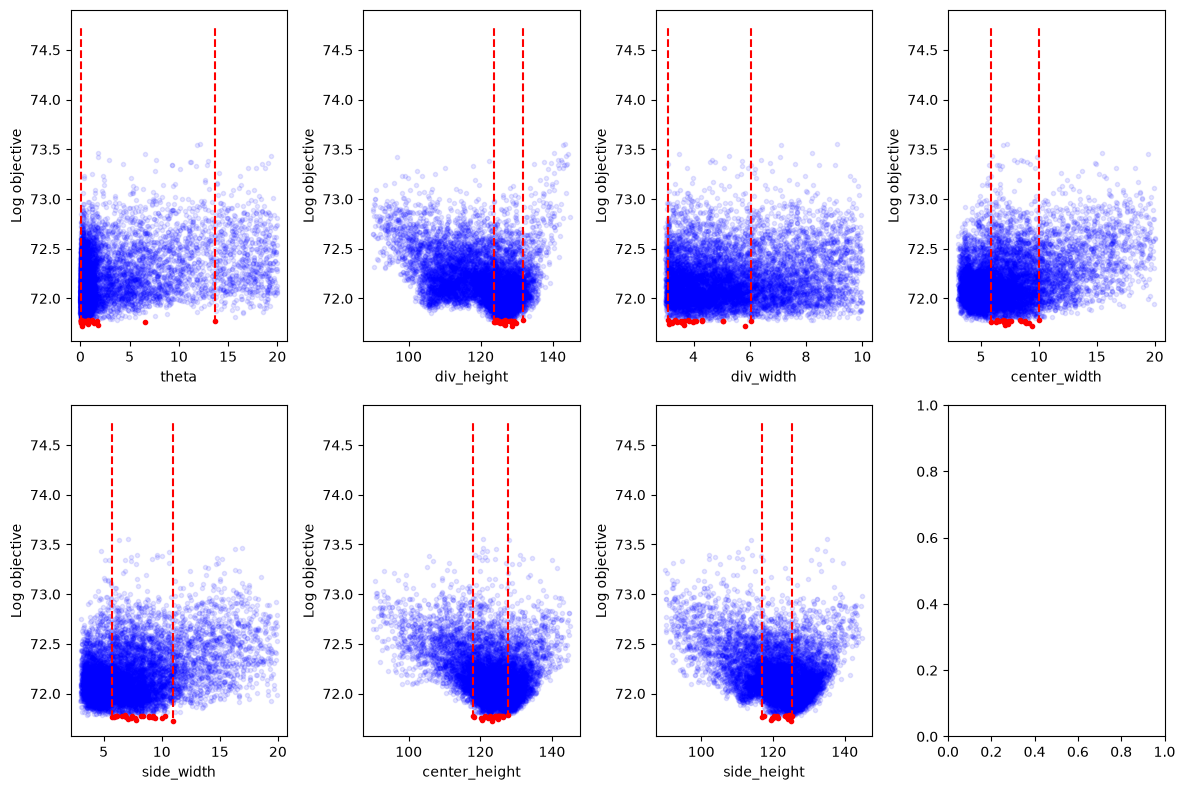

In [8]:
fig, ax = plt.subplots(2, 4, figsize=(12,8))
ax_flat = ax.flatten()

n = 25
tn_params = params_arr[best][:n]

for i, name in enumerate(param_names):
    #print(f'optimal {name}s: {t10_params[:,i]}\n')
    ax_flat[i].scatter(params_arr[:,i], np.log(values_arr), c='b', marker='.', alpha=0.1)
    ax_flat[i].set_xlabel(name)
    ax_flat[i].set_ylabel("Log objective")
    ax_flat[i].vlines([np.min(tn_params[:,i]), np.max(tn_params[:,i])], 71.75, 74.75, colors='r', ls='--')
    print(f'range for {name}: {[np.min(tn_params[:,i]), np.max(tn_params[:,i])]}')
    ax_flat[i].scatter(tn_params[:,i], np.log(values_arr[best][:n]), c='r', marker='.')

plt.tight_layout()
plt.show()

In [35]:
print(mcmc.fom([43.08239729, 128.44919526, 5.33452249, 9.99969355, 6.26901851, 6.59042247, 125.13866136, 123.95102582], verbose=True))
print()
print(mcmc.fom([0, 128.44919526, 5.33452249, 10, 6.26901851, 6.59042247, 125.13866136, 123.95102582], verbose=True))


  x= -0.00 y=  0.00  guess= 15.000  f= 15.008 GHz  C=0.5124  Q=    7618  loc=0.451
  x= -0.58 y=  0.55  guess= 14.173  f= 14.206 GHz  C=0.2609  Q=    7695  loc=0.178
  x= -1.17 y=  1.09  guess= 13.433  f= 13.473 GHz  C=0.2611  Q=    7929  loc=0.173
  x= -1.75 y=  1.64  guess= 12.766  f= 12.819 GHz  C=0.2532  Q=    8328  loc=0.189
  x= -2.33 y=  2.18  guess= 12.162  f= 12.221 GHz  C=0.2080  Q=    8705  loc=0.163
  x= -2.92 y=  2.73  guess= 11.613  f= 11.646 GHz  C=0.2937  Q=    8765  loc=0.260
  x= -3.50 y=  3.27  guess= 11.111  f= 11.169 GHz  C=0.2068  Q=    9208  loc=0.172
  x= -4.08 y=  3.82  guess= 10.651  f= 10.686 GHz  C=0.2231  Q=    9239  loc=0.199
  x= -4.67 y=  4.36  guess= 10.227  f= 10.279 GHz  C=0.2249  Q=    9212  loc=0.142
  x= -5.25 y=  4.91  guess=  9.836  f=  9.892 GHz  C=0.2314  Q=    9487  loc=0.166
  x= -5.83 y=  5.46  guess=  9.474  f=  9.541 GHz  C=0.2089  Q=    9597  loc=0.148
  x= -6.42 y=  6.00  guess=  9.137  f=  9.216 GHz  C=0.1799  Q=    9825  loc=0.160
  x=

In [ ]:
# stability analysis

nominal_result, samples, summary=stability_analysis.check_stability(best_params, num_samples=3, theta_err=0.1, length_err=0.03)
print(summary)
#print(nominal_result, samples, summary)

[stability] nominal gaps (mm): [10. 10. 10. 10. 10. 10.]
[stability] tolerances: {'width': 0.05, 'height': 0.05, 'position': 0.05, 'cavity_w': 0.05, 'cavity_h': 0.05, 'angle_deg': 1, 'correlated_parts': False}
[stability] 50 samples x 16 tuning steps
[stability] nominal: angle=0.16899349, cav_w=102.96938212, cav_h=160.0, ctr_w=9.41222406, ctr_h=123.2129638, ctr_x=0.0, ctr_y=0.0, divL_w=5.83007533, divL_h=128.74669068, divL_x=-17.621149695, divL_y=0.0, divR_w=5.83007533, divR_h=128.74669068, divR_x=17.621149695, divR_y=0.0, sideL_w=10.9485037, sideL_h=124.9380107, sideL_x=-36.01043921, sideL_y=0.0, sideR_w=10.9485037, sideR_h=124.9380107, sideR_x=36.01043921, sideR_y=0.0
[stability] nominal: FOM=1.40416e+31  meanC=0.2481  meanQ=9180  band 8.100-14.981 GHz (12.5s)
  [1/50] angle=0.9287615787070004, cav_w=103.03044574587088, cav_h=159.8801591330421, ctr_w=9.331756229509887, ctr_h=123.19367442936598, ctr_x=-0.02638290332319339, ctr_y=-0.05138080763016272, divL_w=5.801984682427528, divL_h=1

KeyboardInterrupt: 

KeyboardInterrupt: 

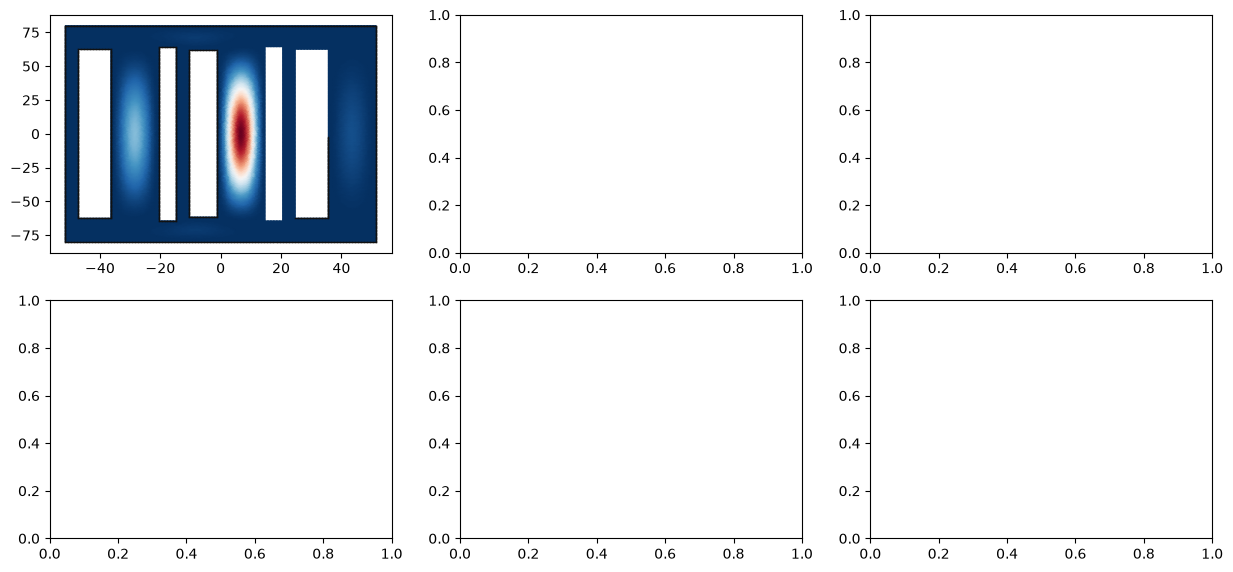

In [78]:
#params_m = mcmc._params_to_m(best_params)
#spec = fem_vis.toaster_spec(params_m, mesh_size=0.001, mesh_uniform=True)
mcmc.sim_sweep([0.16899349, 128.74669068, 5.83007533, 10., 9.41222406,  10.9485037, 123.2129638, 124.9380107], plot_all=True)

#fem_vis.plot_best_modes_magnitude_square(best_params, save='results/08_11_2026_stability_analysis_nominal.png')